In [15]:
pip install --upgrade mediapipe opencv-python

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [16]:
%pip install --upgrade mediapipe opencv-python

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [17]:
import os

base = "/Users/yaminichitikela/Desktop/ISL PROJECT/include_videos"

# One video from 5 different categories
sample_videos = []
categories = ["Colours", "Animals", "Greetings", "People", "Places"]

for cat in categories:
    cat_path = os.path.join(base, cat)
    first_sign = sorted(os.listdir(cat_path))[0]         # first sign folder
    sign_path = os.path.join(cat_path, first_sign)
    first_video = sorted(os.listdir(sign_path))[0]       # first video file
    full_path = os.path.join(sign_path, first_video)
    sample_videos.append((cat, first_sign, full_path))
    print(f"{cat} → {first_sign} → {first_video}")


Colours → 47. Red → MVI_3719.MOV
Animals → 1. Dog → MVI_2978.MOV
Greetings → 48. Hello → MVI_0029.MOV
People → 58. Son → MVI_3753.MOV
Places → 18. City → MVI_3263.MOV


In [18]:
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import numpy as np
import urllib.request
import os

# ── Download model files (only once) ──────────────────────────────────────────
MODEL_DIR = os.path.dirname(os.path.abspath("smoke_test.ipynb"))

HAND_MODEL  = os.path.join(MODEL_DIR, "hand_landmarker.task")
POSE_MODEL  = os.path.join(MODEL_DIR, "pose_landmarker_full.task")

def _download(url, dst):
    if not os.path.exists(dst):
        print(f"Downloading {os.path.basename(dst)} …")
        urllib.request.urlretrieve(url, dst)
        print("  done.")

_download(
    "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task",
    HAND_MODEL,
)
_download(
    "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/1/pose_landmarker_full.task",
    POSE_MODEL,
)

# ── Build detectors ────────────────────────────────────────────────────────────
hand_detector = vision.HandLandmarker.create_from_options(
    vision.HandLandmarkerOptions(
        base_options=python.BaseOptions(model_asset_path=HAND_MODEL),
        num_hands=2,
        min_hand_detection_confidence=0.3,
        min_hand_presence_confidence=0.3,
        min_tracking_confidence=0.3,
    )
)

pose_detector = vision.PoseLandmarker.create_from_options(
    vision.PoseLandmarkerOptions(
        base_options=python.BaseOptions(model_asset_path=POSE_MODEL),
        num_poses=1,
        min_pose_detection_confidence=0.3,
        min_pose_presence_confidence=0.3,
        min_tracking_confidence=0.3,
    )
)

# Upper-body pose indices (same 11 joints as before)
POSE_INDICES = [0, 7, 8, 11, 12, 13, 14, 15, 16, 23, 24]

# ── Keypoint extraction ────────────────────────────────────────────────────────
def extract_keypoints(video_path):
    cap = cv2.VideoCapture(video_path)
    frames_keypoints = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        rgb      = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)

        # ── hands ──
        hand_result = hand_detector.detect(mp_image)
        left_hand   = [[0.0, 0.0, 0.0]] * 21
        right_hand  = [[0.0, 0.0, 0.0]] * 21
        for i, handedness_list in enumerate(hand_result.handedness):
            label     = handedness_list[0].category_name   # "Left" or "Right"
            landmarks = [[lm.x, lm.y, lm.z] for lm in hand_result.hand_landmarks[i]]
            if label == "Left":
                left_hand  = landmarks
            else:
                right_hand = landmarks

        # ── pose ──
        pose_result = pose_detector.detect(mp_image)
        if pose_result.pose_landmarks:
            lms  = pose_result.pose_landmarks[0]
            body = [[lms[i].x, lms[i].y, lms[i].z] for i in POSE_INDICES]
        else:
            body = [[0.0, 0.0, 0.0]] * 11

        frame_kp = left_hand + right_hand + body   # 53 joints × 3 coords
        frames_keypoints.append(frame_kp)

    cap.release()
    return np.array(frames_keypoints)   # shape: (T, 53, 3)


#  Quick test
cat, sign, path = sample_videos[0]
kp = extract_keypoints(path)
print(f"Category : {cat}")
print(f"Sign     : {sign}")
print(f"Video    : {path}")
print(f"Shape    : {kp.shape}")     # (T, 53, 3)
print(f"Frames   : {kp.shape[0]}")
print(f"Joints   : {kp.shape[1]}")  # 53
print(f"Coords   : {kp.shape[2]}")  # 3

I0000 00:00:1777034239.393353 27275703 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M4 Pro
W0000 00:00:1777034239.406523 27275704 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777034239.417772 27275704 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1777034239.466692 27275717 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M4 Pro
W0000 00:00:1777034239.540944 27275718 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777034239.602775 27275718 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Category : Colours
Sign     : 47. Red
Video    : /Users/yaminichitikela/Desktop/ISL PROJECT/include_videos/Colours/47. Red/MVI_3719.MOV
Shape    : (58, 53, 3)
Frames   : 58
Joints   : 53
Coords   : 3


In [19]:
results_summary = []

for cat, sign, path in sample_videos:
    kp = extract_keypoints(path)

    # A frame counts as "missing" only when every joint in the hand block is (0,0,0).
    # axis=(1,2) reduces over both the 21-joint and 3-coord dimensions so we get
    # one boolean per frame, not one per joint.  The old axis=2 reduction produced
    # a (T, 21) array and np.sum counted individual zero-joints, not zero-frames.
    missing_left  = int(np.sum(np.all(kp[:, :21,  :] == 0, axis=(1, 2))))
    missing_right = int(np.sum(np.all(kp[:, 21:42, :] == 0, axis=(1, 2))))

    results_summary.append({
        "category": cat,
        "sign": sign,
        "shape": kp.shape,
        "frames": kp.shape[0],
        "missing_left_hand_frames":  missing_left,
        "missing_right_hand_frames": missing_right,
    })
    print(
        f"{cat}/{sign} → shape={kp.shape}, "
        f"missing left={missing_left}/{kp.shape[0]} frames, "
        f"missing right={missing_right}/{kp.shape[0]} frames"
    )

Colours/47. Red → shape=(58, 53, 3), missing left=0/58 frames, missing right=14/58 frames
Animals/1. Dog → shape=(117, 53, 3), missing left=85/117 frames, missing right=49/117 frames
Greetings/48. Hello → shape=(63, 53, 3), missing left=0/63 frames, missing right=10/63 frames
People/58. Son → shape=(66, 53, 3), missing left=29/66 frames, missing right=19/66 frames
Places/18. City → shape=(90, 53, 3), missing left=15/90 frames, missing right=18/90 frames


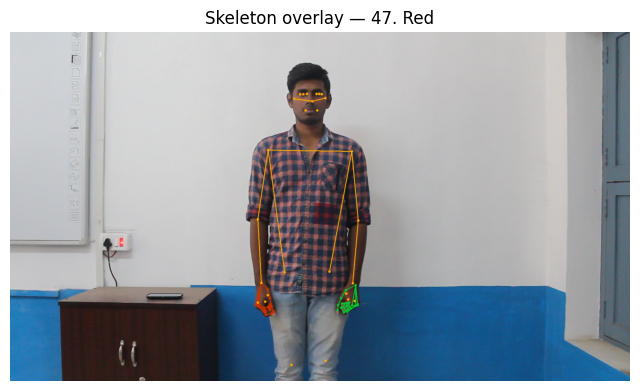

In [20]:
import matplotlib.pyplot as plt

# Skeleton connection tables
HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (0,9),(9,10),(10,11),(11,12),
    (0,13),(13,14),(14,15),(15,16),
    (0,17),(17,18),(18,19),(19,20),
    (5,9),(9,13),(13,17),
]
POSE_CONNECTIONS = [
    (0,7),(0,8),(11,12),
    (11,13),(13,15),(12,14),(14,16),
    (11,23),(12,24),
]

def draw_skeleton(frame, landmarks, connections, color, r=4):
    h, w = frame.shape[:2]
    pts = [(int(lm[0]*w), int(lm[1]*h)) for lm in landmarks]
    for cx, cy in pts:
        cv2.circle(frame, (cx, cy), r, color, -1)
    for a, b in connections:
        if a < len(pts) and b < len(pts):
            cv2.line(frame, pts[a], pts[b], color, 2)

# Grab one frame
cap = cv2.VideoCapture(sample_videos[0][2])
ret, frame = cap.read()
cap.release()

rgb      = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)

hand_result = hand_detector.detect(mp_image)
pose_result = pose_detector.detect(mp_image)

annotated = rgb.copy()

# Draw each detected hand
for i, handedness_list in enumerate(hand_result.handedness):
    label = handedness_list[0].category_name
    color = (0, 200, 50) if label == "Left" else (200, 50, 0)
    lms   = [[lm.x, lm.y, lm.z] for lm in hand_result.hand_landmarks[i]]
    draw_skeleton(annotated, lms, HAND_CONNECTIONS, color)

# Draw pose 
if pose_result.pose_landmarks:
    lms = [[lm.x, lm.y, lm.z] for lm in pose_result.pose_landmarks[0]]
    draw_skeleton(annotated, lms, POSE_CONNECTIONS, (255, 165, 0))

plt.figure(figsize=(8, 6))
plt.imshow(annotated)
plt.title(f"Skeleton overlay — {sample_videos[0][1]}")
plt.axis("off")
plt.show()